## TC 5033
### Text Classifier with RNNs

## Team # 73

- A00959089     Marcelo Ismael López Verdugo
- A01796847     Pedro Cuauhtemoc Marquez Correo
- A01625357     Edson Alejandro Lozano García
- A01796999     Christian Gustavo Martínez Ramírez



<br>

#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


#### Install libraries (if needed)

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

In [ ]:
# !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2

In [ ]:
# !pip install scipy==1.9.3
# !pip install scikit-plot
#you may receive a message of restarting session, this is OK

In [ ]:
# !pip install portalocker
#please restar session after this intallation. After restarting go straight to importing the libraries

## Import libraries

In [8]:
# The following libraries are required for running the given code
# Please feel free to add any libraries you consider adecuate to complete the assingment.
import numpy as np
#PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# neural layers
from torch import nn
from torch.nn import functional as F
from scipy import interp  # type: ignore

import scikitplot as skplt
import matplotlib.pyplot as plt
import gc

ImportError: cannot import name 'interp' from 'scipy' (c:\Users\MLOPE243\OneDrive - azureford\Documents\maestria\Inteligencia artificial avanzada\Github\.venv\lib\site-packages\scipy\__init__.py)

In [ ]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### Get the train and the test datasets and dataloaders

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

In [ ]:
train_dataset, test_dataset = AG_NEWS()
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

RuntimeError: Download directory .data does not exist. Did you create it?

In [4]:
# Get the tokeniser
# tokeniser object
tokeniser = get_tokenizer('basic_english')

def yield_tokens(data):
    for _, text in data:
        yield tokeniser(text)

In [5]:
# Build the vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])

In [6]:
#test tokens
# Due to 'TC5033' does not belong to the vocab it maps to index 0 (<unk>)
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


In [7]:
# Split training data into train (90%) and validation (10%) sets
NUM_TRAIN = int(len(train_dataset)*0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [8]:
# Perform split randomly
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [10]:
print(f'Train dataset:      {len(train_dataset)}')
print(f'Validation dataset: {len(val_dataset)}')
print(f'Test dataset:       {len(test_dataset)}')

Train dataset:      108000
Validation dataset: 12000
Test dataset:       7600


In [12]:
# function passed to the DataLoader to process a batch of data as indicated
# It transforms a list of (label, text) tuples into padded/truncated tensors
def collate_batch(batch):
    # Get label and text
    y, x = list(zip(*batch))

    # Create list with indices from tokeniser
    x = [vocab(tokeniser(text)) for text in x]
    x = [t + ([0]*(max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]

    # Prepare the labels, by subtracting 1 to get them in the range 0-3
    return torch.tensor(x, dtype=torch.int32), torch.tensor(y, dtype=torch.int32) - 1

In [13]:
labels =  ["World", "Sports", "Business", "Sci/Tech"]
max_tokens = 50
BATCH_SIZE = 256

In [14]:
 # Create DataLoader objects for train, validation, and test sets
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)

### Let us build our RNN model

In [15]:
 # Hyperparameters for the model
EMBEDDING_SIZE = 300   # Dimension of each word embedding vector
NEURONS = 256          # Number of hidden units in each GRU layer
LAYERS = 2             # Number of stacked GRU layers
NUM_CLASSES = 4        # Number of output classes (World, Sports, Business, Sci/Tech)

In [16]:
class RNN_Model_1(nn.Module):
    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab),
                                            embedding_dim=embed_size)

        # GRU processes the sequence in both directions to capture
        # context from past AND future tokens.
        self.rnn = nn.GRU(
            input_size=embed_size,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Fully connected output layer: maps from GRU hidden state to class logits.
        self.fc = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        # Convert integer token indices to embedding vectors
        embedded = self.embedding_layer(x.long())

        # Pass the embedded sequence through the GRU
        output, hidden = self.rnn(embedded)

        # Extract the final hidden state of the *last* layer of the stack
        final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Pass through the fully connected layer to get logits
        logits = self.fc(final_hidden)

        return logits

In [17]:
def accuracy(model, loader):
    model.eval()

    correct = 0  # Running count of correct predictions
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == y).sum().item()
            total += y.size(0)

    return correct / total

In [21]:
def train(model, optimiser, epochs=100):
    """
    Trains the model for the given number of epochs.
    Prints training loss and validation accuracy each epoch.

    Args:
        model     : RNN_Model_1 instance
        optimiser : PyTorch optimizer (e.g. Adam)
        epochs    : number of full passes through the training data
    """
    criterion = nn.CrossEntropyLoss()

    model.to(device)
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimiser.zero_grad()
            logits = model(x)
            loss = criterion(logits, y.long())
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        val_acc = accuracy(model, val_loader)

        print(f'Epoch: {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Validation Accuracy: {val_acc:.4f}')

        gc.collect()

    print("\nTraining complete!")

In [22]:
epochs = 10
lr = 0.001
# instantiate model
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)
optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)

In [23]:
train(rnn_model, optimiser=optimiser,  epochs=epochs)

Epoch: 1/10, Loss: 0.4630, Validation Accuracy: 0.9029
Epoch: 2/10, Loss: 0.2181, Validation Accuracy: 0.9143
Epoch: 3/10, Loss: 0.1440, Validation Accuracy: 0.9160
Epoch: 4/10, Loss: 0.0934, Validation Accuracy: 0.9157
Epoch: 5/10, Loss: 0.0565, Validation Accuracy: 0.9157
Epoch: 6/10, Loss: 0.0381, Validation Accuracy: 0.9151
Epoch: 7/10, Loss: 0.0273, Validation Accuracy: 0.9081
Epoch: 8/10, Loss: 0.0220, Validation Accuracy: 0.9089
Epoch: 9/10, Loss: 0.0179, Validation Accuracy: 0.9119
Epoch: 10/10, Loss: 0.0137, Validation Accuracy: 0.9113

Training complete!


In [24]:
# Evaluate final accuracy on the held-out test set
print(f'Test Accuracy: {accuracy(rnn_model, test_loader):.4f}')

Test Accuracy: 0.9117


### Text Sampling

In [25]:
def sample_text(model, loader):
    model.eval()

    x, y = next(iter(loader))
    x = x.to(device)
    y = y.to(device)

    with torch.no_grad():
        logits = model(x)
        predictions = torch.argmax(logits, dim=1)

    # Imprime true label vs predicted label para cada muestra del batch
    for i, (true_idx, pred_idx) in enumerate(zip(y.cpu(), predictions.cpu())):
        true_label = labels[true_idx.item()]
        pred_label = labels[pred_idx.item()]
        correct = '✓' if true_idx == pred_idx else '✗'
        print(f"{i:<5} {true_label:<15} {pred_label:<15} {correct}")

In [26]:
sample_text(rnn_model, test_loader)

0     Sci/Tech        Sci/Tech        ✓
1     World           Business        ✗
2     Sports          Sports          ✓
3     Sports          Sports          ✓
4     Business        Business        ✓
5     World           World           ✓
6     Business        Business        ✓
7     Business        Business        ✓
8     Business        Sci/Tech        ✗
9     Sports          Sports          ✓
10    Sci/Tech        Sci/Tech        ✓
11    Sci/Tech        Sci/Tech        ✓
12    Sports          Sports          ✓
13    Sports          Sports          ✓
14    Business        Business        ✓
15    Sci/Tech        Sci/Tech        ✓
16    Sports          Sports          ✓
17    Business        Business        ✓
18    Sports          Sports          ✓
19    Business        Business        ✓
20    Sci/Tech        Sci/Tech        ✓
21    World           World           ✓
22    World           Business        ✗
23    Sci/Tech        Sci/Tech        ✓
24    Business        Business        ✓


### Confusion Matrix

In [ ]:
def plot_confusion_matrix(model, loader):
    """
    Generates and plots the confusion matrix for the model on the given DataLoader.

    Args:
        model  : trained RNN_Model_1 instance
        loader : DataLoader (typically test_loader)
    """
    model.eval()

    all_preds = []   # Accumulate all predicted labels
    all_labels = []  # Accumulate all ground truth labels

    with torch.no_grad():
        for x_batch, y_batch in loader:
            # Move data to device
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass: compute logits
            logits = model(x_batch)

            # Predicted class = argmax of logits
            preds = torch.argmax(logits, dim=1)

            # Collect predictions and true labels (move to CPU for numpy conversion)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Plot using scikitplot — normalize=True shows proportions per row (recall per class)
    fig, ax = plt.subplots(figsize=(8, 6))
    skplt.metrics.plot_confusion_matrix(
        all_labels,
        all_preds,
        normalize=True,
        title="Confusion Matrix (Normalized) — AG_NEWS Test Set",
        cmap="Blues",
        ax=ax
    )
    # Replace numeric tick labels with class names for readability
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    plt.tight_layout()
    plt.show()


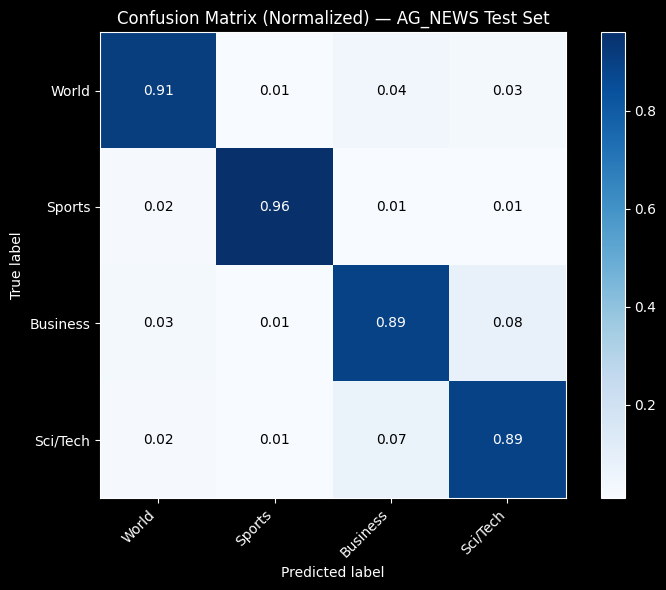

In [31]:
# Generate and display the confusion matrix on the test set
plot_confusion_matrix(rnn_model, test_loader)